# 03 PyCaret 모델링

고혈압 위험 예측을 위한 PyCaret 모델 screening을 진행한다.

## 1. 라이브러리 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Run once if needed
# PyCaret works with Python 3.9, 3.10, or 3.11.
# !pip install pycaret imbalanced-learn lightgbm xgboost

## 2. 정리된 데이터 불러오기

In [3]:
df = pd.read_csv('processed_data/knhanes_young_hypertension_2017_2023.csv')

df.shape

(10974, 15)

In [4]:
df.head()

,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,HE_sbp,HE_dbp,year,covid_period,hypertension
0,39.0,1.0,21.268015,85.0,93.0,1.0,1.0,0.0,1.0,7.0,115.0,78.0,2017,before,0
1,35.0,2.0,20.292201,86.0,98.0,0.0,1.0,0.0,1.0,7.0,105.0,75.0,2017,before,0
2,28.0,2.0,21.950821,98.0,103.0,0.0,1.0,1.0,1.0,7.0,102.0,69.0,2017,before,0
3,37.0,2.0,21.538187,86.0,42.0,1.0,1.0,0.0,1.0,6.0,118.0,77.0,2017,before,0
4,33.0,2.0,20.885981,79.0,150.0,0.0,0.0,0.0,2.0,7.0,95.0,69.0,2017,before,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10974 entries, 0 to 10973
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           10974 non-null  float64
 1   sex           10974 non-null  float64
 2   HE_BMI        10406 non-null  float64
 3   HE_glu        10231 non-null  float64
 4   HE_TG         10232 non-null  float64
 5   sm_presnt     10402 non-null  float64
 6   dr_month      10403 non-null  float64
 7   pa_aerobic    9999 non-null   float64
 8   incm          10945 non-null  float64
 9   educ          10467 non-null  float64
 10  HE_sbp        10319 non-null  float64
 11  HE_dbp        10319 non-null  float64
 12  year          10974 non-null  int64  
 13  covid_period  10974 non-null  object 
 14  hypertension  10974 non-null  int64  
dtypes: float64(12), int64(2), object(1)
memory usage: 1.3+ MB


## 3. Feature와 target 선택

HE_sbp와 HE_dbp는 target을 만들 때만 사용했다. 모델 feature에서는 제외한다.

In [6]:
features = [
    'age', 'sex', 'HE_BMI', 'HE_glu', 'HE_TG',
    'sm_presnt', 'dr_month', 'pa_aerobic',
    'incm', 'educ', 'covid_period'
]

target = 'hypertension'

model_df = df[features + [target]].copy()
model_df.head()

,age,sex,HE_BMI,HE_glu,HE_TG,sm_presnt,dr_month,pa_aerobic,incm,educ,covid_period,hypertension
0,39.0,1.0,21.268015,85.0,93.0,1.0,1.0,0.0,1.0,7.0,before,0
1,35.0,2.0,20.292201,86.0,98.0,0.0,1.0,0.0,1.0,7.0,before,0
2,28.0,2.0,21.950821,98.0,103.0,0.0,1.0,1.0,1.0,7.0,before,0
3,37.0,2.0,21.538187,86.0,42.0,1.0,1.0,0.0,1.0,6.0,before,0
4,33.0,2.0,20.885981,79.0,150.0,0.0,0.0,0.0,2.0,7.0,before,0


In [7]:
model_df.isnull().sum()

age               0
sex               0
HE_BMI          568
HE_glu          743
HE_TG           742
sm_presnt       572
dr_month        571
pa_aerobic      975
incm             29
educ            507
covid_period      0
hypertension      0
dtype: int64

In [8]:
model_df['hypertension'].value_counts()

hypertension
0    10399
1      575
Name: count, dtype: int64

## 4. 간단한 전처리

모델링을 위해 누락값만 간단히 채운다. 이상치는 02 notebook에서 boxplot으로 확인만 했다.

In [9]:
num_cols = ['age', 'HE_BMI', 'HE_glu', 'HE_TG']
cat_cols = ['sex', 'sm_presnt', 'dr_month', 'pa_aerobic', 'incm', 'educ', 'covid_period']

for col in num_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in cat_cols:
    model_df[col] = model_df[col].fillna(model_df[col].mode()[0])

model_df.isnull().sum()

age             0
sex             0
HE_BMI          0
HE_glu          0
HE_TG           0
sm_presnt       0
dr_month        0
pa_aerobic      0
incm            0
educ            0
covid_period    0
hypertension    0
dtype: int64

## 5. PyCaret setup

PyCaret setup에서 범주형 변수 처리, scaling, 클래스 불균형 처리를 함께 진행한다. 수치형 변수에 이상치가 보이므로, 수업에서 다룬 RobustScaler 개념과 가까운 robust normalization을 사용한다.

In [10]:
from pycaret.classification import *

In [11]:
clf = setup(
    data=model_df,
    target='hypertension',
    categorical_features=cat_cols,
    numeric_features=num_cols,
    session_id=123,
    train_size=0.8,
    normalize=True,
    normalize_method='robust',
    fix_imbalance=True,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,123
1,Target,hypertension
2,Target type,Binary
3,Original data shape,"(10974, 12)"
4,Transformed data shape,"(18833, 24)"
5,Transformed train set shape,"(16638, 24)"
6,Transformed test set shape,"(2195, 24)"
7,Numeric features,4
8,Categorical features,7
9,Preprocess,True


## 6. AUC 기준 모델 비교

수업에서 다룬 logistic regression, random forest, boosting, XGBoost, LightGBM 개념을 중심으로 모델을 비교한다. AUC score를 기준으로 상위 3개 모델을 선택한다.

In [12]:
top3_models = compare_models(
    include=['lr', 'rf', 'lightgbm', 'xgboost'],
    sort='AUC',
    n_select=3
)

top3_models

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7403,0.8099,0.7457,0.1373,0.2319,0.1573,0.2400,2.4840
lightgbm,Light Gradient Boosting Machine,0.9432,0.7913,0.0478,0.2731,0.0810,0.0661,0.0945,2.3920
rf,Random Forest Classifier,0.9443,0.7879,0.0109,0.1149,0.0197,0.0118,0.0207,2.1460
xgboost,Extreme Gradient Boosting,0.9405,0.7707,0.0826,0.2669,0.1260,0.1044,0.1239,1.7840


[LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
                importance_type='split', learning_rate=0.1, max_depth=-1,
                min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
                n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
                random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
                subsample_for_bin=200000, subsample_freq=0),
 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max_features='sqrt',
                        max_leaf_nodes=None, max_samples=None,


In [13]:
compare_results = pull()
compare_results

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7403,0.8099,0.7457,0.1373,0.2319,0.1573,0.2400,2.484
lightgbm,Light Gradient Boosting Machine,0.9432,0.7913,0.0478,0.2731,0.0810,0.0661,0.0945,2.392
rf,Random Forest Classifier,0.9443,0.7879,0.0109,0.1149,0.0197,0.0118,0.0207,2.146
xgboost,Extreme Gradient Boosting,0.9405,0.7707,0.0826,0.2669,0.1260,0.1044,0.1239,1.784


AUC 비교 표

상위 모델을 AUC 기준으로 한 번 더 정리한다.

In [14]:
auc_table = compare_results[['Model', 'AUC', 'Accuracy', 'Recall', 'Prec.', 'F1']]
auc_table

,Model,AUC,Accuracy,Recall,Prec.,F1
lr,Logistic Regression,0.8099,0.7403,0.7457,0.1373,0.2319
lightgbm,Light Gradient Boosting Machine,0.7913,0.9432,0.0478,0.2731,0.0810
rf,Random Forest Classifier,0.7879,0.9443,0.0109,0.1149,0.0197
xgboost,Extreme Gradient Boosting,0.7707,0.9405,0.0826,0.2669,0.1260


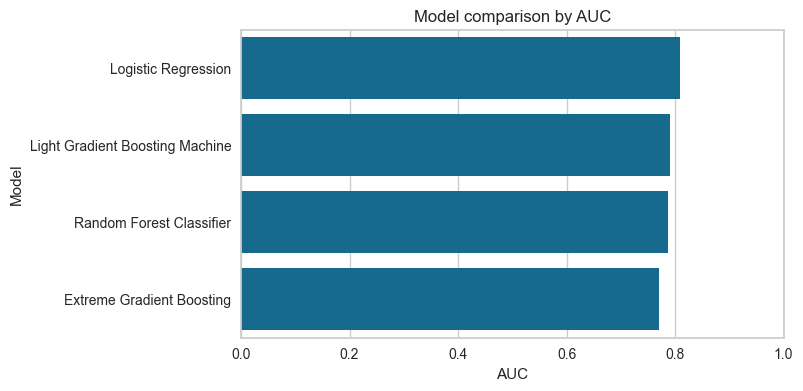

In [15]:
plt.figure(figsize=(7, 4))
sns.barplot(data=auc_table.reset_index(), x='AUC', y='Model')
plt.title('Model comparison by AUC')
plt.xlim(0, 1)
plt.show()

비교 결과, AUC 기준으로는 선형 모델인 Logistic Regression이 가장 좋게 나타났다. 데이터가 많은 특징을 갖는 대규모 데이터라기보다, 선택한 변수가 간단하기 때문에 복잡한 모델보다 안정적으로 작동한 것으로 보인다.

## 7. Best model 튜닝

상위 3개 중 가장 좋은 모델 1개만 간단히 tuning한다.

In [16]:
best_model = top3_models[0]
tuned_best_model = tune_model(best_model, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7449,0.8130,0.7609,0.1411,0.2381,0.1642,0.2499
1,0.7153,0.7833,0.6957,0.1194,0.2038,0.1256,0.1993
2,0.7454,0.8246,0.7717,0.1429,0.2411,0.1675,0.2551
3,0.7432,0.8106,0.7283,0.1359,0.2291,0.1544,0.2342
4,0.7578,0.8276,0.7717,0.1495,0.2504,0.1783,0.2653
Mean,0.7413,0.8118,0.7457,0.1378,0.2325,0.1580,0.2407
Std,0.0140,0.0157,0.0296,0.0101,0.0159,0.0179,0.0230


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [17]:
tune_results = pull()
tune_results

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7449,0.8130,0.7609,0.1411,0.2381,0.1642,0.2499
1,0.7153,0.7833,0.6957,0.1194,0.2038,0.1256,0.1993
2,0.7454,0.8246,0.7717,0.1429,0.2411,0.1675,0.2551
3,0.7432,0.8106,0.7283,0.1359,0.2291,0.1544,0.2342
4,0.7578,0.8276,0.7717,0.1495,0.2504,0.1783,0.2653
Mean,0.7413,0.8118,0.7457,0.1378,0.2325,0.1580,0.2407
Std,0.0140,0.0157,0.0296,0.0101,0.0159,0.0179,0.0230


## 8. 상위 3개 모델 시각화

상위 3개 모델에 대해 confusion matrix, ROC curve, feature importance를 확인한다. 모델에 따라 feature importance가 지원되지 않을 수도 있다.

In [18]:
# Use the tuned model for rank 1.
# Use the selected models from compare_models for rank 2 and rank 3.
plot_models = [tuned_best_model, top3_models[1], top3_models[2]]

Model 1


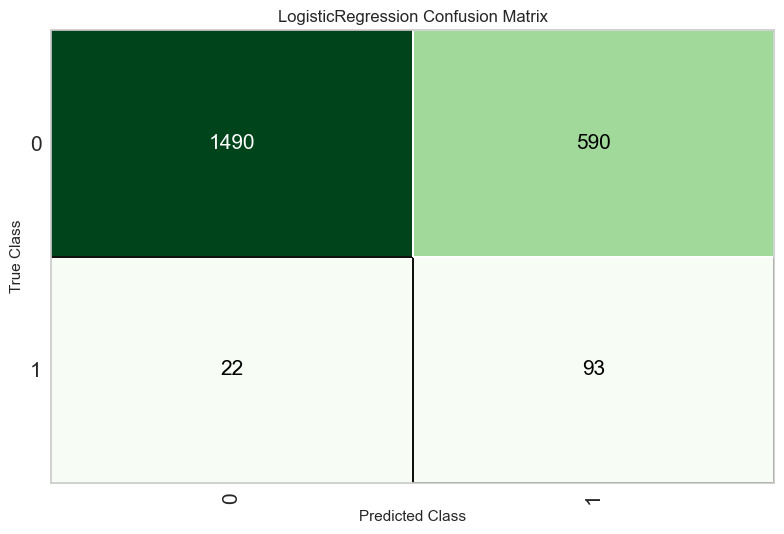

Model 2


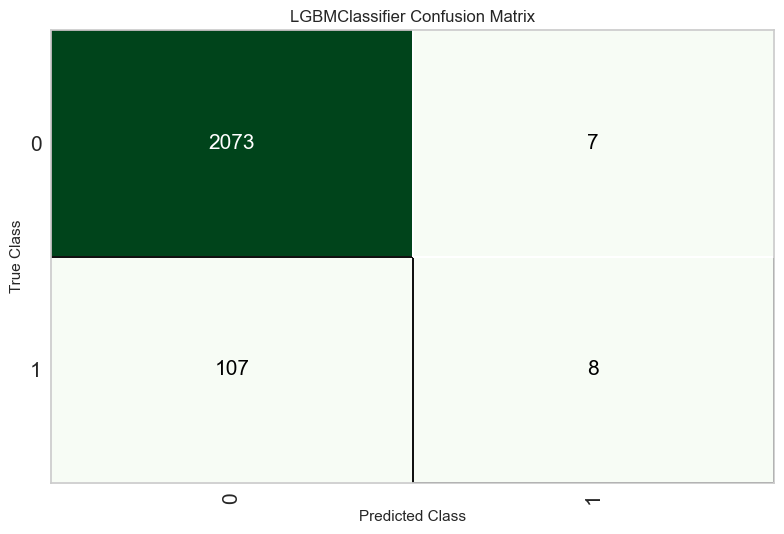

Model 3


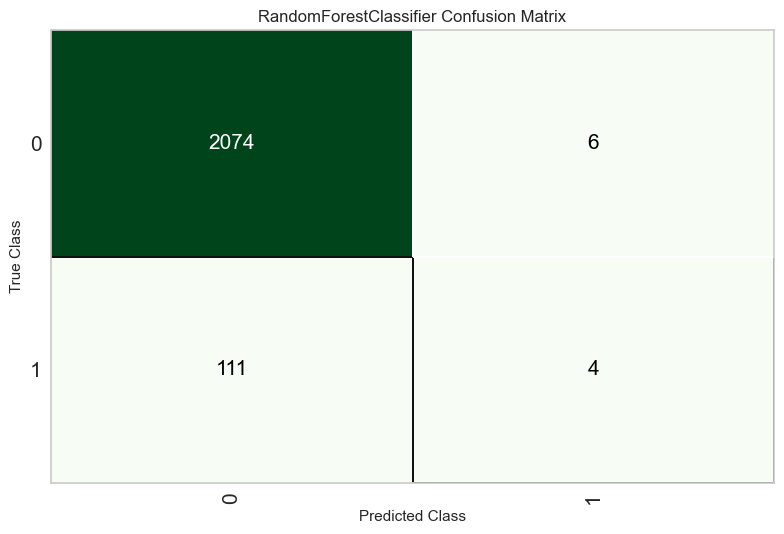

In [19]:
for i, model in enumerate(plot_models, start=1):
    print('Model', i)
    plot_model(model, plot='confusion_matrix')

오차 행렬을 통해 실제 고혈압 그룹을 얼마나 잘 찾는지 확인한다. 고혈압 그룹이 적기 때문에 accuracy만보다 recall과 AUC를 함께 보는 것이 중요하다.

Model 1


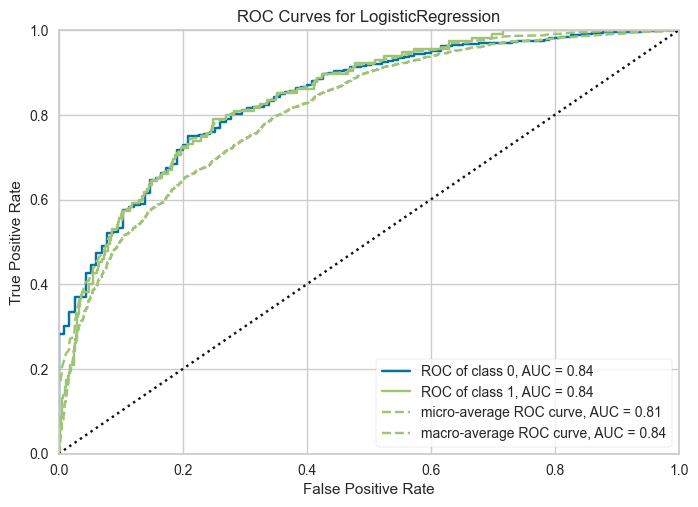

Model 2


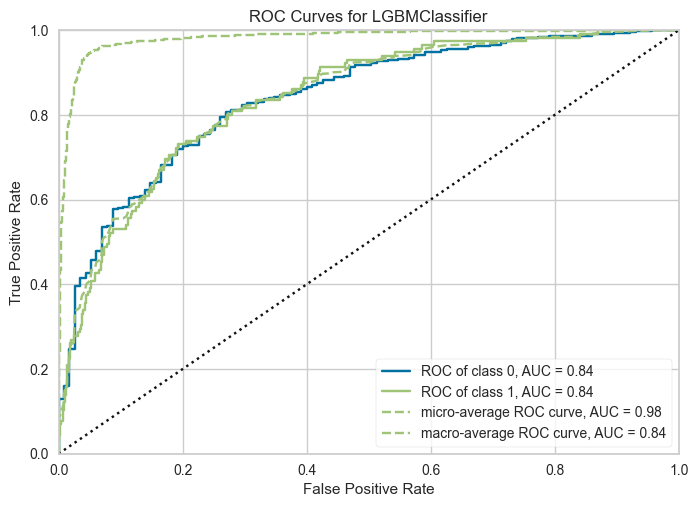

Model 3


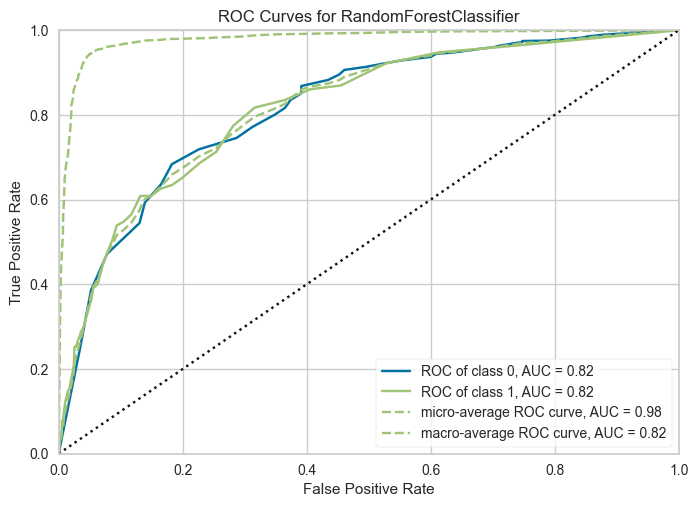

In [20]:
for i, model in enumerate(plot_models, start=1):
    print('Model', i)
    plot_model(model, plot='auc')

ROC curve는 모델의 분류 성능을 threshold에 따라 확인할 수 있는 그래프이다. 이 과제에서는 AUC score를 상위 모델 선정 기준으로 사용했다.

Model 1


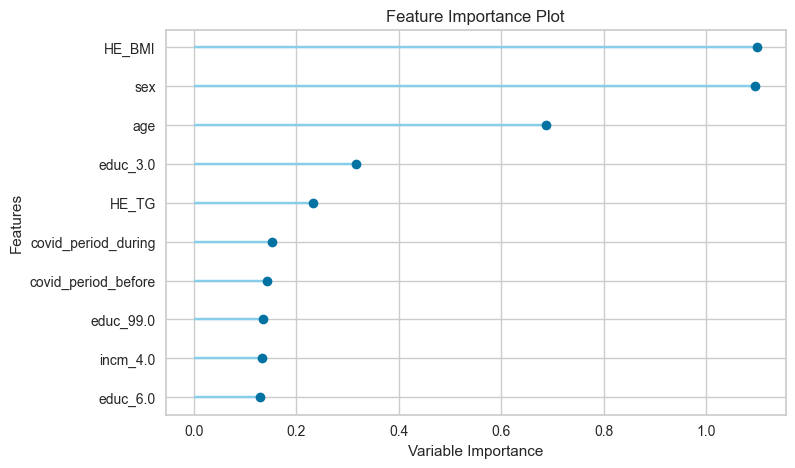

Model 2


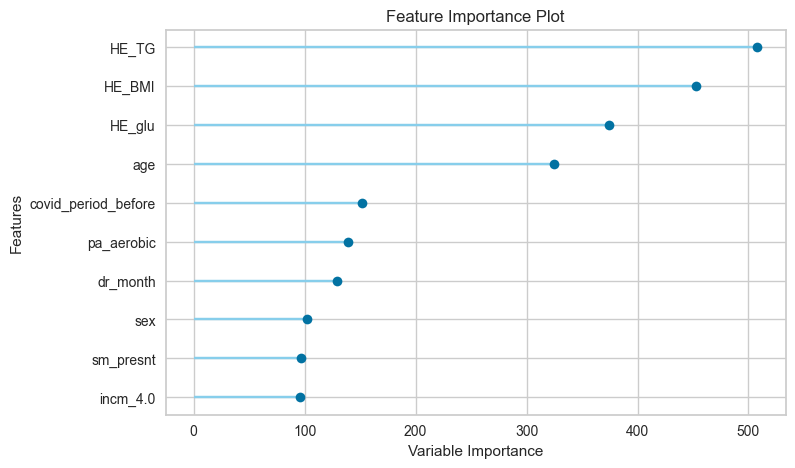

Model 3


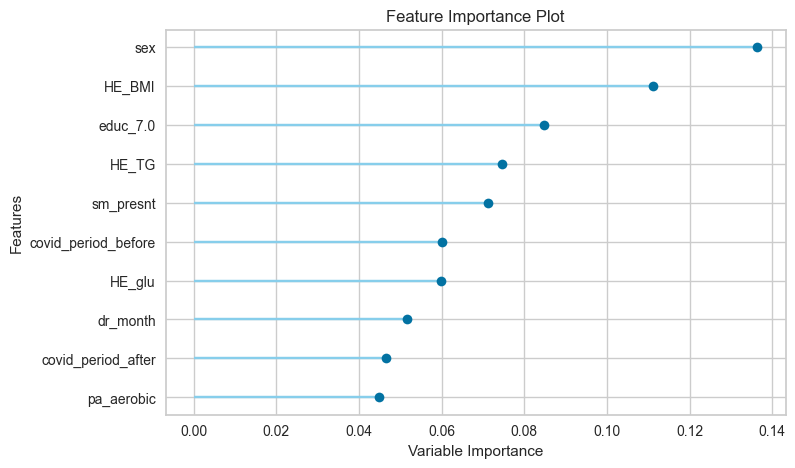

In [21]:
for i, model in enumerate(plot_models, start=1):
    print('Model', i)
    try:
        plot_model(model, plot='feature')
    except Exception as e:
        print('Feature importance is not available for this model.')

Feature importance를 보면 age, BMI, glucose, triglycerides, lifestyle 관련 변수들이 예측에 어떤 정도로 기여하는지 간단히 확인할 수 있다. COVID period는 건강 행태와 시기 차이를 반영하는 변수로 해석할 수 있다.

## 9. 간단 정리

이 notebook에서는 PyCaret을 사용해 모델을 screening하고, AUC 기준 상위 3개 모델을 확인했다. 가장 좋은 모델은 간단히 tuning하고, 과제 요구사항에 맞게 confusion matrix, ROC curve, feature importance를 시각화했다.